# Prototype 1.5

This uses the kaggle dataset being the NJ Transit + Amtrak (NEC) Rail Performance


The baseline pipeline: load → clean → label → features → time split → Logistic Regression → PR-AUC + confusion matrix.


THis version uses the 3 months of data and makes a more fleshed out version of the original version 1 which had only 1 month of data.

Depending on the platfrom the file path will always be different.

In [ ]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)


In [ ]:
#import dataset and show table
#3 months of data
df = pd.read_csv("/content/2018_03.csv")
df = pd.read_csv("/content/2018_04.csv")
df = pd.read_csv("/content/2018_05.csv")
df.head()


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type
0,2018-05-01,3926,1.0,Trenton,148.0,Trenton,148.0,2018-05-01 07:31:00,2018-05-01 07:35:13,4.216667,departed,Northeast Corrdr,NJ Transit
1,2018-05-01,3926,2.0,Trenton,148.0,Hamilton,32905.0,2018-05-01 07:38:00,2018-05-01 07:40:10,2.166667,departed,Northeast Corrdr,NJ Transit
2,2018-05-01,3926,3.0,Hamilton,32905.0,Princeton Junction,125.0,2018-05-01 07:45:00,2018-05-01 07:46:09,1.150000,departed,Northeast Corrdr,NJ Transit
3,2018-05-01,3926,4.0,Princeton Junction,125.0,Newark Penn Station,107.0,2018-05-01 08:22:00,2018-05-01 08:24:02,2.033333,departed,Northeast Corrdr,NJ Transit
4,2018-05-01,3926,5.0,Newark Penn Station,107.0,Secaucus Upper Lvl,38187.0,2018-05-01 08:30:00,2018-05-01 08:35:12,5.200000,departed,Northeast Corrdr,NJ Transit


In [ ]:
#Load + concatenate all 3
dfs = []
for f in files:
    temp = pd.read_csv(f)
    temp["source_file"] = f.split("/")[-1]  # keeps track of month source
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Combined shape:", df.shape)
print(df["source_file"].value_counts())
df.head()

Combined shape: (779612, 14)
source_file
2018_05.csv    266837
2018_03.csv    256508
2018_04.csv    256267
Name: count, dtype: int64


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type,source_file
0,2018-03-01,3805,1.0,New York Penn Station,105.0,New York Penn Station,105.0,2018-03-02 01:22:00,2018-03-02 01:21:05,0.000000,departed,Northeast Corrdr,NJ Transit,2018_03.csv
1,2018-03-01,3805,2.0,New York Penn Station,105.0,Secaucus Upper Lvl,38187.0,2018-03-02 01:31:00,2018-03-02 01:31:08,0.133333,departed,Northeast Corrdr,NJ Transit,2018_03.csv
2,2018-03-01,3805,3.0,Secaucus Upper Lvl,38187.0,Newark Penn Station,107.0,2018-03-02 01:40:00,2018-03-02 01:40:07,0.116667,departed,Northeast Corrdr,NJ Transit,2018_03.csv
3,2018-03-01,3805,4.0,Newark Penn Station,107.0,Newark Airport,37953.0,2018-03-02 01:45:00,2018-03-02 01:45:10,0.166667,departed,Northeast Corrdr,NJ Transit,2018_03.csv
4,2018-03-01,3805,5.0,Newark Airport,37953.0,North Elizabeth,109.0,2018-03-02 01:49:00,2018-03-02 01:49:10,0.166667,departed,Northeast Corrdr,NJ Transit,2018_03.csv


In [ ]:
#sanity checks

print("Columns:", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values (top 15):")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\nDate range (raw):")
if "date" in df.columns:
    print(df["date"].min(), "to", df["date"].max())

Columns: ['date', 'train_id', 'stop_sequence', 'from', 'from_id', 'to', 'to_id', 'scheduled_time', 'actual_time', 'delay_minutes', 'status', 'line', 'type', 'source_file']

Data types:

date               object
train_id           object
stop_sequence     float64
from               object
from_id           float64
to                 object
to_id             float64
scheduled_time     object
actual_time        object
delay_minutes     float64
status             object
line               object
type               object
source_file        object
dtype: object

Missing values (top 15):
stop_sequence     39766
scheduled_time    39766
delay_minutes     39766
to_id               159
from_id             159
train_id              0
to                    0
from                  0
date                  0
actual_time           0
status                0
line                  0
type                  0
source_file           0
dtype: int64

Date range (raw):
2018-03-01 to 2018-05-31


In [ ]:
#cleaning and formatting

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Parse numeric fields
df["delay_minutes"] = pd.to_numeric(df["delay_minutes"], errors="coerce")
df["stop_sequence"] = pd.to_numeric(df["stop_sequence"], errors="coerce")

# Parse time-like columns
# These can full timestamps or time strings depending on the file format
for col in ["scheduled_time", "actual_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Drop rows missing the key fields we need
df = df.dropna(subset=["date", "delay_minutes"]).copy()

print("After cleaning:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print(df[["date", "delay_minutes"]].head())

After cleaning: (739846, 14)
Date range: 2018-03-01 00:00:00 to 2018-05-31 00:00:00
        date  delay_minutes
0 2018-03-01       0.000000
1 2018-03-01       0.133333
2 2018-03-01       0.116667
3 2018-03-01       0.166667
4 2018-03-01       0.166667


count    739846.000000
mean          3.588517
std           6.151045
min           0.000000
50%           2.150000
75%           4.150000
90%           7.383333
95%          11.250000
99%          29.300000
max         111.183333
Name: delay_minutes, dtype: float64


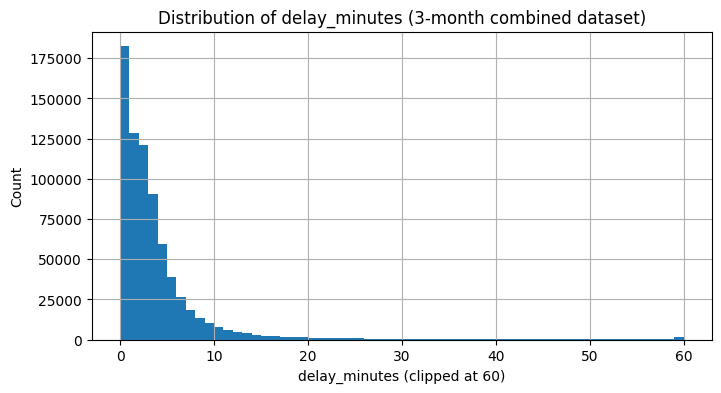

In [ ]:
# raw delay column

print(df["delay_minutes"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8,4))
df["delay_minutes"].clip(upper=60).hist(bins=60)
plt.xlabel("delay_minutes (clipped at 60)")
plt.ylabel("Count")
plt.title("Distribution of delay_minutes (3-month combined dataset)")
plt.show()

In [ ]:
#Create the segment key (from and to)

# Segment = from station -> to station (prefer IDs if present)
if "from_id" in df.columns and "to_id" in df.columns:
    df["segment_id"] = df["from_id"].astype(str) + "->" + df["to_id"].astype(str)
else:
    df["segment_id"] = df["from"].astype(str) + "->" + df["to"].astype(str)

print("Unique segments:", df["segment_id"].nunique())
df[["from", "to", "segment_id"]].head()

Unique segments: 546


,from,to,segment_id
0,New York Penn Station,New York Penn Station,105.0->105.0
1,New York Penn Station,Secaucus Upper Lvl,105.0->38187.0
2,Secaucus Upper Lvl,Newark Penn Station,38187.0->107.0
3,Newark Penn Station,Newark Airport,107.0->37953.0
4,Newark Airport,North Elizabeth,37953.0->109.0


In [ ]:
#Create basic features using more data

# The Time-based features
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Mon, 6=Sun
df["month"] = df["date"].dt.month

# Hour from scheduled_time
if "scheduled_time" in df.columns:
    df["sched_hour"] = df["scheduled_time"].dt.hour
else:
    df["sched_hour"] = 0

# Fill any missing feature values safely
df["stop_sequence"] = df["stop_sequence"].fillna(0)
df["sched_hour"] = df["sched_hour"].fillna(0)

In [ ]:
#Build a reusable feature matrix

USE_STATUS_FEATURE = False  #t

feature_cols_num = ["day_of_week", "month", "sched_hour", "stop_sequence"]
feature_cols_cat = []

for c in ["line", "type"]:
    if c in df.columns:
        feature_cols_cat.append(c)

if USE_STATUS_FEATURE and "status" in df.columns:
    feature_cols_cat.append("status")

X_base = df[feature_cols_num + feature_cols_cat].copy()
X_base = pd.get_dummies(X_base, columns=feature_cols_cat, drop_first=True)

print("X_base shape:", X_base.shape)
X_base.head()

X_base shape: (739846, 14)


,day_of_week,month,sched_hour,stop_sequence,line_Bergen Co. Line,line_Gladstone Branch,line_Main Line,line_Montclair-Boonton,line_Morristown Line,line_No Jersey Coast,line_Northeast Corrdr,line_Pascack Valley,line_Princeton Shuttle,line_Raritan Valley
0,3,3,1,1.0,False,False,False,False,False,False,True,False,False,False
1,3,3,1,2.0,False,False,False,False,False,False,True,False,False,False
2,3,3,1,3.0,False,False,False,False,False,False,True,False,False,False
3,3,3,1,4.0,False,False,False,False,False,False,True,False,False,False
4,3,3,1,5.0,False,False,False,False,False,False,True,False,False,False


In [ ]:
#Helper function to run the full pipeline for any threshold

def run_binary_prototype(df_in, X_in, threshold_min=5, split_ratio=0.7, verbose=True):
    data = df_in.copy()

    # Create label from delay threshold
    data["disruption"] = (data["delay_minutes"] >= threshold_min).astype(int)

    # Sort by time (important)
    data = data.sort_values("date").copy()
    X_sorted = X_in.loc[data.index].copy()
    y_sorted = data["disruption"].copy()

    # Time-based split
    split_idx = int(len(data) * split_ratio)
    X_train = X_sorted.iloc[:split_idx]
    y_train = y_sorted.iloc[:split_idx]
    X_test  = X_sorted.iloc[split_idx:]
    y_test  = y_sorted.iloc[split_idx:]

    # Baseline model
    model = LogisticRegression(max_iter=2000, class_weight="balanced")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    ap = average_precision_score(y_test, y_prob)  # PR-AUC
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    result = {
        "threshold_min": threshold_min,
        "n_rows": len(data),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "positive_rate_all": data["disruption"].mean(),
        "positive_rate_train": y_train.mean(),
        "positive_rate_test": y_test.mean(),
        "pr_auc_ap": ap,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "y_test": y_test,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "model": model
    }

    if verbose:
        print(f"\n=== Threshold >= {threshold_min} min ===")
        print(f"Rows: {len(data):,} | Train: {len(X_train):,} | Test: {len(X_test):,}")
        print(f"Positive rate (all/train/test): "
              f"{result['positive_rate_all']:.4f} / {result['positive_rate_train']:.4f} / {result['positive_rate_test']:.4f}")
        print(f"PR-AUC (AP): {ap:.4f}")
        print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
        print("Confusion matrix:\n", cm)

    return result

In [ ]:
#Run the 3-month Prototype 1 (threshold = 5 min)
res_5 = run_binary_prototype(df, X_base, threshold_min=5, split_ratio=0.7, verbose=True)


=== Threshold >= 5 min ===
Rows: 739,846 | Train: 517,892 | Test: 221,954
Positive rate (all/train/test): 0.2127 / 0.2117 / 0.2151
PR-AUC (AP): 0.2901
Precision: 0.2621 | Recall: 0.7791 | F1: 0.3922
Confusion matrix:
 [[ 69480 104731]
 [ 10547  37196]]


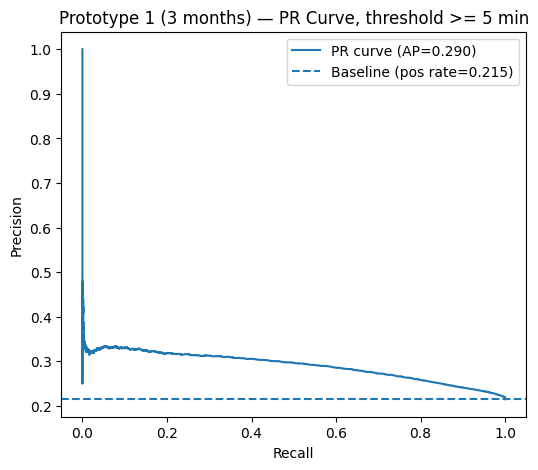

In [ ]:
#Plot the PR curve (threshold = 5 min)

precision_vals, recall_vals, _ = precision_recall_curve(res_5["y_test"], res_5["y_prob"])

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR curve (AP={res_5['pr_auc_ap']:.3f})")
plt.axhline(res_5["positive_rate_test"], linestyle="--", label=f"Baseline (pos rate={res_5['positive_rate_test']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Prototype 1 (3 months) — PR Curve, threshold >= 5 min")
plt.legend()
plt.show()


In [ ]:
#Compare thresholds (5, 30, 60) on the same 3 month dataset

results = []
store = {}

for t in [5, 30, 60]:
    r = run_binary_prototype(df, X_base, threshold_min=t, split_ratio=0.7, verbose=False)
    store[t] = r
    results.append({
        "threshold_min": t,
        "positive_rate_all": r["positive_rate_all"],
        "positive_rate_test": r["positive_rate_test"],
        "pr_auc_ap": r["pr_auc_ap"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "train_rows": r["train_rows"],
        "test_rows": r["test_rows"]
    })

results_df = pd.DataFrame(results)
results_df

,threshold_min,positive_rate_all,positive_rate_test,pr_auc_ap,precision,recall,f1,train_rows,test_rows
0,5,0.212744,0.215103,0.290078,0.262078,0.779088,0.392218,517892,221954
1,30,0.009952,0.007772,0.013043,0.012725,0.480000,0.024792,517892,221954
2,60,0.002290,0.001608,0.003447,0.001870,0.100840,0.003671,517892,221954


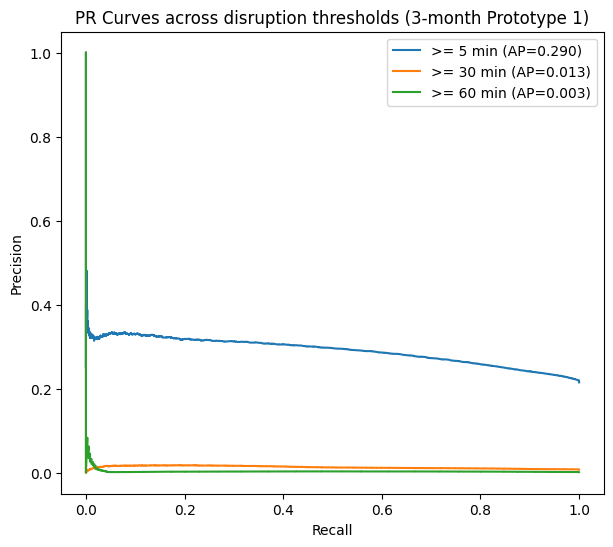

In [ ]:
#Plot PR curves for 5 / 30 / 60 together
plt.figure(figsize=(7,6))

for t in [5, 30, 60]:
    r = store[t]
    p, rc, _ = precision_recall_curve(r["y_test"], r["y_prob"])
    plt.plot(rc, p, label=f">= {t} min (AP={r['pr_auc_ap']:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves across disruption thresholds (3-month Prototype 1)")
plt.legend()
plt.show()